In [220]:
import pandas as pd
from datetime import date, datetime
import matplotlib.pyplot as plt

# Yêu cầu 1: Đọc & làm sạch dữ liệu

- ### Đọc cả 3 sheet bằng Pandas

In [66]:
file_path = "danso_khong_trung_tinh.xlsx"

# Đọc file excel bằng pandas
df_dan_so = pd.read_excel(file_path, sheet_name=None)

# Đọc 3 sheets
df_hien_tai = df_dan_so['DanSoHienTai']
df_nam_truoc = df_dan_so['DanSoNamTruoc']
df_hoc_van = df_dan_so['NhomHocVan']

print(df_hien_tai)
print("-" * 60)

print(df_nam_truoc)
print("-" * 60)

print(df_hoc_van)

      TinhThanh  DanSo (người)  DanSo_LaoDong (người)  ThatNghiep (người)  \
0        Hà Nội        8568808                4724942              111511   
1        TP.HCM       10306537                6375132              168870   
2       Đà Nẵng       10903618                5916462               83838   
3     Hải Phòng        1464277                 664521               10367   
4       Cần Thơ        4677309                3009541               81629   
..          ...            ...                    ...                 ...   
58     Trà Vinh        8850953                4176521              122223   
59  Tuyên Quang        4042627                2324715              153182   
60    Vĩnh Long       11326283                6551101               86206   
61    Vĩnh Phúc        6747777                3402923               65776   
62      Yên Bái       10510280                5611254               64462   

   HocVanPhoBien  
0    Sau đại học  
1    Sau đại học  
2        Đại học  

- ### Chuẩn hóa tên tỉnh: viết hoa chữ cái đầu

In [259]:
df_hien_tai['TinhThanh'] = df_hien_tai['TinhThanh'].str.title()
print(df_hien_tai)

      TinhThanh  DanSo (người)  DanSo_LaoDong (người)  ThatNghiep (người)  \
0        Hà Nội        8568808                4724942              111511   
1        Tp.Hcm       10306537                6375132              168870   
2       Đà Nẵng       10903618                5916462               83838   
3     Hải Phòng        1464277                 664521               10367   
4       Cần Thơ        4677309                3009541               81629   
..          ...            ...                    ...                 ...   
58     Trà Vinh        8850953                4176521              122223   
59  Tuyên Quang        4042627                2324715              153182   
60    Vĩnh Long       11326283                6551101               86206   
61    Vĩnh Phúc        6747777                3402923               65776   
62      Yên Bái       10510280                5611254               64462   

   HocVanPhoBien  
0    Sau đại học  
1    Sau đại học  
2        Đại học  

In [258]:
df_nam_truoc['TinhThanh'] = df_nam_truoc['TinhThanh'].str.title()
print(df_nam_truoc)

      TinhThanh  DanSo_NamTruoc (người)  LaoDong_NamTruoc (người)
0        Hà Nội                 8538374                   4719690
1        Tp.Hcm                10275401                   6371478
2       Đà Nẵng                10894146                   5911323
3     Hải Phòng                 1436488                    658698
4       Cần Thơ                 4641492                   3008228
..          ...                     ...                       ...
58     Trà Vinh                 8838300                   4170697
59  Tuyên Quang                 4007667                   2321160
60    Vĩnh Long                11305889                   6551079
61    Vĩnh Phúc                 6740399                   3398716
62      Yên Bái                10487292                   5603570

[63 rows x 3 columns]


#### Kiểm tra và chuyển cột số về kiểu int và Xử lý giá trị âm hoặc thiếu (nếu có)

In [69]:
def check_number_column(dataFrame):
    
    df_clean = dataFrame.copy()
    
    for col in df_clean.columns:
        if pd.api.types.is_numeric_dtype(df_clean[col]):
            avg_value = df_clean[col].mean()
            # Check cột có ô bị thiếu thì diền avg value vào ô bị trống
            df_clean[col] = df_clean[col].fillna(avg_value)
            # đổi type int64
            df_clean[col] = df_clean[col].round().astype('int64')
            # Xử lý số âm
            df_clean[col] = df_clean[col].abs()
            
    return df_clean

In [70]:
df_hien_tai_clean = check_number_column(df_hien_tai)
df_nam_truoc_clean = check_number_column(df_nam_truoc)

print(df_hien_tai_clean)
print("-" * 60)
print(df_nam_truoc_clean)

      TinhThanh  DanSo (người)  DanSo_LaoDong (người)  ThatNghiep (người)  \
0        Hà Nội        8568808                4724942              111511   
1        Tp.Hcm       10306537                6375132              168870   
2       Đà Nẵng       10903618                5916462               83838   
3     Hải Phòng        1464277                 664521               10367   
4       Cần Thơ        4677309                3009541               81629   
..          ...            ...                    ...                 ...   
58     Trà Vinh        8850953                4176521              122223   
59  Tuyên Quang        4042627                2324715              153182   
60    Vĩnh Long       11326283                6551101               86206   
61    Vĩnh Phúc        6747777                3402923               65776   
62      Yên Bái       10510280                5611254               64462   

   HocVanPhoBien  
0    Sau đại học  
1    Sau đại học  
2        Đại học  

In [71]:
print(df_hien_tai_clean.dtypes)
print("-" * 60)
print(df_nam_truoc_clean.dtypes)

TinhThanh                  str
DanSo (người)            int64
DanSo_LaoDong (người)    int64
ThatNghiep (người)       int64
HocVanPhoBien              str
dtype: object
------------------------------------------------------------
TinhThanh                     str
DanSo_NamTruoc (người)      int64
LaoDong_NamTruoc (người)    int64
dtype: object


# **Yêu cầu 2: Gộp dữ liệu (Tạo ra cột mới)**

- Gộp Sheet 1 và Sheet 2 theo TinhThanh

In [72]:
df_merged = pd.merge(df_hien_tai_clean, df_nam_truoc_clean, how='inner')
df_merged

,TinhThanh,DanSo (người),DanSo_LaoDong (người),ThatNghiep (người),HocVanPhoBien,DanSo_NamTruoc (người),LaoDong_NamTruoc (người)
0,Hà Nội,8568808,4724942,111511,Sau đại học,8538374,4719690
1,Tp.Hcm,10306537,6375132,168870,Sau đại học,10275401,6371478
2,Đà Nẵng,10903618,5916462,83838,Đại học,10894146,5911323
3,Hải Phòng,1464277,664521,10367,Đại học,1436488,658698
4,Cần Thơ,4677309,3009541,81629,Sau đại học,4641492,3008228
...,...,...,...,...,...,...,...
58,Trà Vinh,8850953,4176521,122223,Sau đại học,8838300,4170697
59,Tuyên Quang,4042627,2324715,153182,THPT,4007667,2321160
60,Vĩnh Long,11326283,6551101,86206,THPT,11305889,6551079
61,Vĩnh Phúc,6747777,3402923,65776,THPT,6740399,3398716


- Gộp thêm Sheet 3 theo HocVanPhoBien

In [73]:
df_final = pd.merge(df_merged, df_hoc_van, how='left', left_on='HocVanPhoBien', right_on='HocVan')
df_final

,TinhThanh,DanSo (người),DanSo_LaoDong (người),ThatNghiep (người),HocVanPhoBien,DanSo_NamTruoc (người),LaoDong_NamTruoc (người),HocVan,TyLeViecLam (%)
0,Hà Nội,8568808,4724942,111511,Sau đại học,8538374,4719690,Sau đại học,98
1,Tp.Hcm,10306537,6375132,168870,Sau đại học,10275401,6371478,Sau đại học,98
2,Đà Nẵng,10903618,5916462,83838,Đại học,10894146,5911323,Đại học,95
3,Hải Phòng,1464277,664521,10367,Đại học,1436488,658698,Đại học,95
4,Cần Thơ,4677309,3009541,81629,Sau đại học,4641492,3008228,Sau đại học,98
...,...,...,...,...,...,...,...,...,...
58,Trà Vinh,8850953,4176521,122223,Sau đại học,8838300,4170697,Sau đại học,98
59,Tuyên Quang,4042627,2324715,153182,THPT,4007667,2321160,THPT,88
60,Vĩnh Long,11326283,6551101,86206,THPT,11305889,6551079,THPT,88
61,Vĩnh Phúc,6747777,3402923,65776,THPT,6740399,3398716,THPT,88


- Tạo bảng dữ liệu tổng hợp duy nhất

In [74]:
# Xóa cột trùng lăp
del df_final['HocVan']
df_final

,TinhThanh,DanSo (người),DanSo_LaoDong (người),ThatNghiep (người),HocVanPhoBien,DanSo_NamTruoc (người),LaoDong_NamTruoc (người),TyLeViecLam (%)
0,Hà Nội,8568808,4724942,111511,Sau đại học,8538374,4719690,98
1,Tp.Hcm,10306537,6375132,168870,Sau đại học,10275401,6371478,98
2,Đà Nẵng,10903618,5916462,83838,Đại học,10894146,5911323,95
3,Hải Phòng,1464277,664521,10367,Đại học,1436488,658698,95
4,Cần Thơ,4677309,3009541,81629,Sau đại học,4641492,3008228,98
...,...,...,...,...,...,...,...,...
58,Trà Vinh,8850953,4176521,122223,Sau đại học,8838300,4170697,98
59,Tuyên Quang,4042627,2324715,153182,THPT,4007667,2321160,88
60,Vĩnh Long,11326283,6551101,86206,THPT,11305889,6551079,88
61,Vĩnh Phúc,6747777,3402923,65776,THPT,6740399,3398716,88


# **Yêu cầu 3: Tính toán & phân tích**

In [75]:
# a. Tính tỷ lệ thất nghiệp
df_final['TyLeThatNghiep (%)'] = df_final['ThatNghiep (người)'] / df_final['DanSo_LaoDong (người)'] * 100
df_final

,TinhThanh,DanSo (người),DanSo_LaoDong (người),ThatNghiep (người),HocVanPhoBien,DanSo_NamTruoc (người),LaoDong_NamTruoc (người),TyLeViecLam (%),TyLeThatNghiep (%)
0,Hà Nội,8568808,4724942,111511,Sau đại học,8538374,4719690,98,2.360050
1,Tp.Hcm,10306537,6375132,168870,Sau đại học,10275401,6371478,98,2.648886
2,Đà Nẵng,10903618,5916462,83838,Đại học,10894146,5911323,95,1.417029
3,Hải Phòng,1464277,664521,10367,Đại học,1436488,658698,95,1.560071
4,Cần Thơ,4677309,3009541,81629,Sau đại học,4641492,3008228,98,2.712341
...,...,...,...,...,...,...,...,...,...
58,Trà Vinh,8850953,4176521,122223,Sau đại học,8838300,4170697,98,2.926431
59,Tuyên Quang,4042627,2324715,153182,THPT,4007667,2321160,88,6.589281
60,Vĩnh Long,11326283,6551101,86206,THPT,11305889,6551079,88,1.315901
61,Vĩnh Phúc,6747777,3402923,65776,THPT,6740399,3398716,88,1.932926


In [76]:
# b. Phân loại mức thất nghiệp
def phan_loai_that_nghiep(rate):
    if rate < 2:
        return 'Rất Thấp'
    elif 2 <= rate < 4:
        return 'Thấp'
    elif 4 <= rate <= 6:
        return 'Trung Bình'
    else:
        return 'Cao'

In [77]:
df_final['MucThatNghiep'] = df_final['TyLeThatNghiep (%)'].apply(phan_loai_that_nghiep)
df_final.head(20)

,TinhThanh,DanSo (người),DanSo_LaoDong (người),ThatNghiep (người),HocVanPhoBien,DanSo_NamTruoc (người),LaoDong_NamTruoc (người),TyLeViecLam (%),TyLeThatNghiep (%),MucThatNghiep
0,Hà Nội,8568808,4724942,111511,Sau đại học,8538374,4719690,98,2.360050,Thấp
1,Tp.Hcm,10306537,6375132,168870,Sau đại học,10275401,6371478,98,2.648886,Thấp
2,Đà Nẵng,10903618,5916462,83838,Đại học,10894146,5911323,95,1.417029,Rất Thấp
3,Hải Phòng,1464277,664521,10367,Đại học,1436488,658698,95,1.560071,Rất Thấp
4,Cần Thơ,4677309,3009541,81629,Sau đại học,4641492,3008228,98,2.712341,Thấp
5,An Giang,4437360,2428761,123213,Sau đại học,4433359,2421052,98,5.073080,Trung Bình
6,Bà Rịa - Vũng Tàu,6250465,3352885,40008,THPT,6227034,3348613,88,1.193241,Rất Thấp
7,Bắc Giang,6190152,3817843,120421,THPT,6156838,3814019,88,3.154163,Thấp
8,Bắc Kạn,10593853,6101858,274481,Sau đại học,10564505,6101477,98,4.498318,Trung Bình
9,Bạc Liêu,2910393,1720415,57010,Sau đại học,2906506,1715003,98,3.313735,Thấp


In [78]:
# c. Tính tăng trưởng dân số & lao động
df_final['TangDanSo'] = df_final['DanSo (người)'] - df_final['DanSo_NamTruoc (người)']
df_final['TangLaoDong'] = df_final['DanSo_LaoDong (người)'] - df_final['LaoDong_NamTruoc (người)']

In [79]:
df_final.head(50)

,TinhThanh,DanSo (người),DanSo_LaoDong (người),ThatNghiep (người),HocVanPhoBien,DanSo_NamTruoc (người),LaoDong_NamTruoc (người),TyLeViecLam (%),TyLeThatNghiep (%),MucThatNghiep,TangDanSo,TangLaoDong
0,Hà Nội,8568808,4724942,111511,Sau đại học,8538374,4719690,98,2.360050,Thấp,30434,5252
1,Tp.Hcm,10306537,6375132,168870,Sau đại học,10275401,6371478,98,2.648886,Thấp,31136,3654
2,Đà Nẵng,10903618,5916462,83838,Đại học,10894146,5911323,95,1.417029,Rất Thấp,9472,5139
3,Hải Phòng,1464277,664521,10367,Đại học,1436488,658698,95,1.560071,Rất Thấp,27789,5823
4,Cần Thơ,4677309,3009541,81629,Sau đại học,4641492,3008228,98,2.712341,Thấp,35817,1313
5,An Giang,4437360,2428761,123213,Sau đại học,4433359,2421052,98,5.073080,Trung Bình,4001,7709
6,Bà Rịa - Vũng Tàu,6250465,3352885,40008,THPT,6227034,3348613,88,1.193241,Rất Thấp,23431,4272
7,Bắc Giang,6190152,3817843,120421,THPT,6156838,3814019,88,3.154163,Thấp,33314,3824
8,Bắc Kạn,10593853,6101858,274481,Sau đại học,10564505,6101477,98,4.498318,Trung Bình,29348,381
9,Bạc Liêu,2910393,1720415,57010,Sau đại học,2906506,1715003,98,3.313735,Thấp,3887,5412


In [80]:
# d. 
# 10 tỉnh thất nghiệp cao nhất
top10_tinh_that_nghiep_cao_nhat = df_final.nlargest(10, columns='TyLeThatNghiep (%)')[['TinhThanh', 'TyLeThatNghiep (%)', 'MucThatNghiep']]

# 10 tỉnh thất nghiệp thấp nhất
top10_tinh_that_nghiep_thap_nhat = df_final.nsmallest(10, columns='TyLeThatNghiep (%)')[['TinhThanh', 'TyLeThatNghiep (%)', 'MucThatNghiep']]

# 10 tỉnh tăng dân số cao nhất
top10_tinh_tang_dan_so_cao_nhat = df_final.nlargest(10, columns='TangDanSo')[['TinhThanh', 'TangDanSo']]

In [81]:
top10_tinh_that_nghiep_cao_nhat

,TinhThanh,TyLeThatNghiep (%),MucThatNghiep
24,Hà Giang,6.899553,Cao
13,Bình Định,6.869703,Cao
30,Hưng Yên,6.780680,Cao
59,Tuyên Quang,6.589281,Cao
49,Quảng Trị,6.507077,Cao
55,Thanh Hóa,6.461975,Cao
36,Lào Cai,6.406111,Cao
47,Quảng Ngãi,5.970211,Trung Bình
50,Sóc Trăng,5.946310,Trung Bình
25,Hà Nam,5.764148,Trung Bình


In [82]:
top10_tinh_that_nghiep_thap_nhat

,TinhThanh,TyLeThatNghiep (%),MucThatNghiep
62,Yên Bái,1.148798,Rất Thấp
46,Quảng Nam,1.170692,Rất Thấp
6,Bà Rịa - Vũng Tàu,1.193241,Rất Thấp
44,Phú Yên,1.200548,Rất Thấp
60,Vĩnh Long,1.315901,Rất Thấp
2,Đà Nẵng,1.417029,Rất Thấp
3,Hải Phòng,1.560071,Rất Thấp
56,Thừa Thiên Huế,1.725808,Rất Thấp
22,Đồng Tháp,1.790484,Rất Thấp
53,Thái Bình,1.847942,Rất Thấp


In [83]:
top10_tinh_tang_dan_so_cao_nhat

,TinhThanh,TangDanSo
48,Quảng Ninh,38977
54,Thái Nguyên,38379
56,Thừa Thiên Huế,37593
52,Tây Ninh,36611
10,Bắc Ninh,36551
43,Phú Thọ,36348
39,Nam Định,36281
4,Cần Thơ,35817
53,Thái Bình,35116
34,Lai Châu,35061


## e. Phân tích học vấn:

#### **Tỷ lệ phân bố học vấn THEO tỉnh không đủ dữ liệu để làm theo tỉnh, mỗi tỉnh/thành chỉ được cung cấp duy nhất một cột là HocVanPhoBien, Đề bài hoàn toàn không có dữ liệu về số lượng người cụ thể của từng cấp bậc học**

In [84]:
# Tỷ lệ phân bố trình độ học vấn phổ biến giữa các tỉnh (%)
ty_le_hoc_van = df_final['HocVanPhoBien'].value_counts(normalize=True) * 100

In [85]:
ty_le_hoc_van

HocVanPhoBien
Sau đại học    28.571429
Cao đẳng       26.984127
Đại học        22.222222
THPT           22.222222
Name: proportion, dtype: float64

In [90]:
# Tỷ lệ việc làm (từ sheet 3) gắn vào từng tỉnh
# Học vấn phổ biến mang lại tỷ lệ việc làm cao nhất
ty_le_viec_lam_theo_tinh = df_final.nlargest(len(df_final) ,columns='TyLeViecLam (%)')[['TinhThanh', 'HocVanPhoBien', 'TyLeViecLam (%)']]

In [91]:
ty_le_viec_lam_theo_tinh.head(10)

,TinhThanh,HocVanPhoBien,TyLeViecLam (%)
0,Hà Nội,Sau đại học,98
1,Tp.Hcm,Sau đại học,98
4,Cần Thơ,Sau đại học,98
5,An Giang,Sau đại học,98
8,Bắc Kạn,Sau đại học,98
9,Bạc Liêu,Sau đại học,98
11,Bến Tre,Sau đại học,98
16,Cà Mau,Sau đại học,98
24,Hà Giang,Sau đại học,98
31,Khánh Hòa,Sau đại học,98


# **BÀI TẬP: PHÂN TÍCH DOANH THU & TIÊU THỤ HÀNG HÓA CHUỖI CỬA HÀNG TIỆN LỢI SHOP K+**

### Yêu cầu 1 — Đọc & Làm sạch dữ liệu (20 điểm)

#### 1. Đọc đủ 3 sheet bằng pandas.

In [105]:
file_path_tien_loi = 'data_CuaHangTienLoi_ShopKhai.xlsx'
df_cua_hang = pd.read_excel(file_path_tien_loi, sheet_name='CuaHang')
df_hang_hoa = pd.read_excel(file_path_tien_loi, sheet_name='HangHoa')
df_giao_dich = pd.read_excel(file_path_tien_loi, sheet_name='GiaoDich')


In [106]:
df_cua_hang.head()

,MaCuaHang,TenCuaHang,TinhThanh,QuanHuyen,ViTri,DienTich_m2,SoNhanVien
0,CH001,Shop K+ HCM CN1,HCM,Quận 3,Trung tâm thương mại,70,8
1,CH002,Shop K+ HCM CN2,HCM,Bình Thạnh,Văn phòng,111,8
2,CH003,Shop K+ HCM CN3,HCM,Phú Nhuận,Văn phòng,92,5
3,CH004,Shop K+ HCM CN4,HCM,Bình Thạnh,Trường học,65,12
4,CH005,Shop K+ HCM CN5,HCM,Quận 1,Trường học,86,11


In [260]:
df_hang_hoa.head()

,MaHang,TenHang,DanhMuc,GiaBan,NhaCungCap
0,SP0001,Coca Cola - Gói nhỏ,Đồ uống,11,CocaCola
1,SP0002,Coca Cola - Gói lớn,Đồ uống,45,Unilever
2,SP0003,Coca Cola - Hộp,Đồ uống,44,Ostar
3,SP0004,Coca Cola - Chai,Đồ uống,49,Orion
4,SP0005,Coca Cola - Lon,Đồ uống,32,Unilever


In [261]:
df_giao_dich.head()

,MaGD,MaCuaHang,MaHang,SoLuong,Ngay
0,GD00001,CH013,SP0080,31,2024-04-24
1,GD00002,CH017,SP0037,25,2024-01-08
2,GD00003,CH009,SP0042,11,2024-03-09
3,GD00004,CH007,SP0043,42,2024-01-16
4,GD00005,CH012,SP0098,12,2024-04-04


#### 2 .Chuẩn hóa tên tỉnh/thành, tên quận/huyện (ví dụ: in hoa/thường, loại bỏ khoảng trắng thừa).

In [108]:
df_cua_hang['TinhThanh'] = df_cua_hang['TinhThanh'].astype('str').str.title().str.strip()
df_cua_hang['QuanHuyen'] = df_cua_hang['QuanHuyen'].astype('str').str.title().str.strip()
df_cua_hang.head(10)

,MaCuaHang,TenCuaHang,TinhThanh,QuanHuyen,ViTri,DienTich_m2,SoNhanVien
0,CH001,Shop K+ HCM CN1,Hcm,Quận 3,Trung tâm thương mại,70,8
1,CH002,Shop K+ HCM CN2,Hcm,Bình Thạnh,Văn phòng,111,8
2,CH003,Shop K+ HCM CN3,Hcm,Phú Nhuận,Văn phòng,92,5
3,CH004,Shop K+ HCM CN4,Hcm,Bình Thạnh,Trường học,65,12
4,CH005,Shop K+ HCM CN5,Hcm,Quận 1,Trường học,86,11
5,CH006,Shop K+ Hà Nội CN6,Hà Nội,Cầu Giấy,Trung tâm thương mại,167,10
6,CH007,Shop K+ Hà Nội CN7,Hà Nội,Hà Đông,Trường học,123,7
7,CH008,Shop K+ Hà Nội CN8,Hà Nội,Hoàn Kiếm,Khu công nghiệp,124,7
8,CH009,Shop K+ Hà Nội CN9,Hà Nội,Cầu Giấy,Khu dân cư,128,10
9,CH010,Shop K+ Hà Nội CN10,Hà Nội,Hoàn Kiếm,Trường học,144,4


#### 3. Kiểm tra giá trị null, trùng lặp trên toàn bộ dữ liệu.

In [149]:
print(f'Cua hang null: \n{df_cua_hang.isna().sum()}')
print('-' * 100)
print(f'hang hoa null: \n{df_hang_hoa.isna().sum()}')
print('-' * 100)
print(f'Giao dịch null: \n{df_giao_dich.isna().sum()}')
print('-' * 100)
print(f'Cua hang duplicated: \n{df_giao_dich.duplicated().sum()}')
print('-' * 100)
print(f'Hang hoa duplicated: \n{df_giao_dich.duplicated().sum()}')
print('-' * 100)
print(f'Giao dịch duplicated: \n{df_giao_dich.duplicated().sum()}')

Cua hang null: 
MaCuaHang      0
TenCuaHang     0
TinhThanh      0
QuanHuyen      0
ViTri          0
DienTich_m2    0
SoNhanVien     0
dtype: int64
----------------------------------------------------------------------------------------------------
hang hoa null: 
MaHang        0
TenHang       0
DanhMuc       0
GiaBan        0
NhaCungCap    0
dtype: int64
----------------------------------------------------------------------------------------------------
Giao dịch null: 
MaGD         0
MaCuaHang    0
MaHang       0
SoLuong      0
Ngay         0
dtype: int64
----------------------------------------------------------------------------------------------------
Cua hang duplicated: 
0
----------------------------------------------------------------------------------------------------
Hang hoa duplicated: 
0
----------------------------------------------------------------------------------------------------
Giao dịch duplicated: 
0


#### 4.Chuyển kiểu dữ liệu (Type Casting):

In [148]:
# Ngay → datetime
df_giao_dich['Ngay'] = pd.to_datetime(df_giao_dich['Ngay'])

# SoLuong → int 
df_giao_dich['SoLuong'] = df_giao_dich['SoLuong'].astype('int64')
# GiaBan → int
df_hang_hoa['GiaBan'] = df_hang_hoa['GiaBan'].astype('int64')

print(f'df giao dich: \n{df_giao_dich.dtypes}')
print('-' * 50)
print(f'df hang hoa: \n{df_hang_hoa.dtypes}')

df giao dich: 
MaGD                    str
MaCuaHang               str
MaHang                  str
SoLuong               int64
Ngay         datetime64[us]
dtype: object
--------------------------------------------------
df hang hoa: 
MaHang          str
TenHang         str
DanhMuc         str
GiaBan        int64
NhaCungCap      str
dtype: object


In [151]:
df_giao_dich

,MaGD,MaCuaHang,MaHang,SoLuong,Ngay
0,GD00001,CH013,SP0080,31,2024-04-24
1,GD00002,CH017,SP0037,25,2024-01-08
2,GD00003,CH009,SP0042,11,2024-03-09
3,GD00004,CH007,SP0043,42,2024-01-16
4,GD00005,CH012,SP0098,12,2024-04-04
...,...,...,...,...,...
9995,GD09996,CH018,SP0069,20,2024-01-17
9996,GD09997,CH007,SP0099,31,2024-02-15
9997,GD09998,CH015,SP0048,33,2024-04-06
9998,GD09999,CH005,SP0109,1,2024-04-22


### Yêu cầu 2 — Gộp dữ liệu (15 điểm)

#### Gộp dữ liệu theo 3 bảng để tạo ra bảng phân tích tổng hợp df_all:

In [158]:
# GiaoDich → gộp với HangHoa theo MaHang
df_all = pd.merge(df_giao_dich, df_hang_hoa, how='left', on='MaHang')

# gộp tiếp với CuaHang theo MaCuaHang
df_all = pd.merge(df_all, df_cua_hang, how='left', on='MaCuaHang')
df_all.head(20)

,MaGD,MaCuaHang,MaHang,SoLuong,Ngay,TenHang,DanhMuc,GiaBan,NhaCungCap,TenCuaHang,TinhThanh,QuanHuyen,ViTri,DienTich_m2,SoNhanVien
0,GD00001,CH013,SP0080,31,2024-04-24,Xúc xích Würst - Gói lớn,Thực phẩm,51,Unilever,Shop K+ Đà Nẵng CN13,Đà Nẵng,Hải Châu,Khu dân cư,125,9
1,GD00002,CH017,SP0037,25,2024-01-08,Red Bull - Gói nhỏ,Đồ uống,40,PepsiCo,Shop K+ Cần Thơ CN17,Cần Thơ,Ninh Kiều,Trung tâm thương mại,76,8
2,GD00003,CH009,SP0042,11,2024-03-09,Red Bull - Túi,Đồ uống,48,Nestlé,Shop K+ Hà Nội CN9,Hà Nội,Cầu Giấy,Khu dân cư,128,10
3,GD00004,CH007,SP0043,42,2024-01-16,Snack Khoai Tây BBQ - Gói nhỏ,Snack,49,CocaCola,Shop K+ Hà Nội CN7,Hà Nội,Hà Đông,Trường học,123,7
4,GD00005,CH012,SP0098,12,2024-04-04,Nước rửa tay Lifebuoy - Gói lớn,Gia dụng,49,Acecook,Shop K+ Đà Nẵng CN12,Đà Nẵng,Thanh Khê,Khu dân cư,94,11
5,GD00006,CH012,SP0085,48,2024-02-05,Cơm nắm Rong biển - Gói nhỏ,Thực phẩm,52,PepsiCo,Shop K+ Đà Nẵng CN12,Đà Nẵng,Thanh Khê,Khu dân cư,94,11
6,GD00007,CH003,SP0056,33,2024-03-08,Bánh Que Vị Bơ - Gói lớn,Snack,48,CocaCola,Shop K+ HCM CN3,Hcm,Phú Nhuận,Văn phòng,92,5
7,GD00008,CH016,SP0114,33,2024-02-25,Hạt điều rang muối - Túi,Đồ khô,50,Ostar,Shop K+ Cần Thơ CN16,Cần Thơ,Ninh Kiều,Trường học,127,6
8,GD00009,CH017,SP0042,17,2024-03-31,Red Bull - Túi,Đồ uống,48,Nestlé,Shop K+ Cần Thơ CN17,Cần Thơ,Ninh Kiều,Trung tâm thương mại,76,8
9,GD00010,CH003,SP0051,49,2024-04-18,Snack Rong Biển - Hộp,Snack,43,Orion,Shop K+ HCM CN3,Hcm,Phú Nhuận,Văn phòng,92,5


### Yêu cầu 3 — Tính toán & Phân tích thống kê (65 điểm)

#### 1. Tạo thêm các cột:

In [205]:
# DoanhThu = SoLuong × GiaBan
df_all['DoanhThu'] = df_all['SoLuong'] * df_all['GiaBan']
# Thang = tháng của cột Ngay
df_all['Thang'] = df_all['Ngay'].dt.month
df_all.head(20)

,MaGD,MaCuaHang,MaHang,SoLuong,Ngay,TenHang,DanhMuc,GiaBan,NhaCungCap,TenCuaHang,TinhThanh,QuanHuyen,ViTri,DienTich_m2,SoNhanVien,DoanhThu,Thang
0,GD00001,CH013,SP0080,31,2024-04-24,Xúc xích Würst - Gói lớn,Thực phẩm,51,Unilever,Shop K+ Đà Nẵng CN13,Đà Nẵng,Hải Châu,Khu dân cư,125,9,1581,4
1,GD00002,CH017,SP0037,25,2024-01-08,Red Bull - Gói nhỏ,Đồ uống,40,PepsiCo,Shop K+ Cần Thơ CN17,Cần Thơ,Ninh Kiều,Trung tâm thương mại,76,8,1000,1
2,GD00003,CH009,SP0042,11,2024-03-09,Red Bull - Túi,Đồ uống,48,Nestlé,Shop K+ Hà Nội CN9,Hà Nội,Cầu Giấy,Khu dân cư,128,10,528,3
3,GD00004,CH007,SP0043,42,2024-01-16,Snack Khoai Tây BBQ - Gói nhỏ,Snack,49,CocaCola,Shop K+ Hà Nội CN7,Hà Nội,Hà Đông,Trường học,123,7,2058,1
4,GD00005,CH012,SP0098,12,2024-04-04,Nước rửa tay Lifebuoy - Gói lớn,Gia dụng,49,Acecook,Shop K+ Đà Nẵng CN12,Đà Nẵng,Thanh Khê,Khu dân cư,94,11,588,4
5,GD00006,CH012,SP0085,48,2024-02-05,Cơm nắm Rong biển - Gói nhỏ,Thực phẩm,52,PepsiCo,Shop K+ Đà Nẵng CN12,Đà Nẵng,Thanh Khê,Khu dân cư,94,11,2496,2
6,GD00007,CH003,SP0056,33,2024-03-08,Bánh Que Vị Bơ - Gói lớn,Snack,48,CocaCola,Shop K+ HCM CN3,Hcm,Phú Nhuận,Văn phòng,92,5,1584,3
7,GD00008,CH016,SP0114,33,2024-02-25,Hạt điều rang muối - Túi,Đồ khô,50,Ostar,Shop K+ Cần Thơ CN16,Cần Thơ,Ninh Kiều,Trường học,127,6,1650,2
8,GD00009,CH017,SP0042,17,2024-03-31,Red Bull - Túi,Đồ uống,48,Nestlé,Shop K+ Cần Thơ CN17,Cần Thơ,Ninh Kiều,Trung tâm thương mại,76,8,816,3
9,GD00010,CH003,SP0051,49,2024-04-18,Snack Rong Biển - Hộp,Snack,43,Orion,Shop K+ HCM CN3,Hcm,Phú Nhuận,Văn phòng,92,5,2107,4


#### 2. Phân tích tổng quan:

In [174]:
# Tổng doanh thu toàn hệ thống
tong_doanh_thu = df_all['DoanhThu'].sum()
print(f'Tổng doanh thu toàn hệ thống: {tong_doanh_thu:,},000 vnd')

Tổng doanh thu toàn hệ thống: 10,887,732,000 vnd


In [175]:
# Doanh thu theo từng cửa hàng
doanh_thu_theo_cua_hang = df_all.groupby(['MaCuaHang', 'TenCuaHang'])['DoanhThu'].sum().reset_index()
doanh_thu_theo_cua_hang.head(20)

,MaCuaHang,TenCuaHang,DoanhThu
0,CH001,Shop K+ HCM CN1,523302
1,CH002,Shop K+ HCM CN2,486532
2,CH003,Shop K+ HCM CN3,578165
3,CH004,Shop K+ HCM CN4,565084
4,CH005,Shop K+ HCM CN5,509127
5,CH006,Shop K+ Hà Nội CN6,550121
6,CH007,Shop K+ Hà Nội CN7,493936
7,CH008,Shop K+ Hà Nội CN8,613951
8,CH009,Shop K+ Hà Nội CN9,511904
9,CH010,Shop K+ Hà Nội CN10,551079


In [176]:
# Doanh thu theo từng tỉnh/thành
doanh_thu_theo_tung_tinh = df_all.groupby(['TinhThanh'])['DoanhThu'].sum().reset_index()
doanh_thu_theo_tung_tinh.head(20)

,TinhThanh,DoanhThu
0,Cần Thơ,2783305
1,Hcm,2662210
2,Hà Nội,2720991
3,Đà Nẵng,2721226


In [178]:
# Doanh thu theo danh mục sản phẩm
doanh_thu_theo_san_pham = df_all.groupby(['DanhMuc'])['DoanhThu'].sum().reset_index()
doanh_thu_theo_san_pham.head(20)

,DanhMuc,DoanhThu
0,Gia dụng,1386644
1,Snack,2087692
2,Thực phẩm,1987563
3,Đồ khô,1649950
4,Đồ uống,3775883


#### 3. Sản phẩm & Cửa hàng:

In [186]:
# Top 10 sản phẩm bán chạy nhất (theo SoLuong)
top_10_san_pham_ban_chay = df_all.groupby(['MaHang', 'TenHang'])['SoLuong'].sum().reset_index().nlargest(10, 'SoLuong')
top_10_san_pham_ban_chay

,MaHang,TenHang,SoLuong
122,SP0123,Hạnh nhân mỹ - Hộp,3041
41,SP0042,Red Bull - Túi,3038
116,SP0117,Đậu phộng tỏi ớt - Hộp,3034
39,SP0040,Red Bull - Chai,2972
8,SP0009,Pepsi - Hộp,2964
111,SP0112,Hạt điều rang muối - Chai,2964
4,SP0005,Coca Cola - Lon,2943
60,SP0061,Snack Gà Cay - Gói nhỏ,2936
66,SP0067,Mì Hảo Hảo - Gói nhỏ,2869
89,SP0090,Cơm nắm Rong biển - Túi,2820


In [187]:
# Top 10 sản phẩm có doanh thu cao nhất
top_10_san_pham_doanh_thu_cao_nhat = df_all.groupby(['MaHang', 'TenHang'])['DoanhThu'].sum().reset_index().nlargest(10, 'DoanhThu')
top_10_san_pham_doanh_thu_cao_nhat

,MaHang,TenHang,DoanhThu
39,SP0040,Red Bull - Chai,178320
122,SP0123,Hạnh nhân mỹ - Hộp,161173
96,SP0097,Nước rửa tay Lifebuoy - Gói nhỏ,160716
60,SP0061,Snack Gà Cay - Gói nhỏ,149736
16,SP0017,7Up - Lon,146880
117,SP0118,Đậu phộng tỏi ớt - Chai,146720
41,SP0042,Red Bull - Túi,145824
52,SP0053,Snack Rong Biển - Lon,144368
119,SP0120,Đậu phộng tỏi ớt - Túi,139240
20,SP0021,Twister Cam - Hộp,138824


In [188]:
# Top 5 cửa hàng doanh thu cao nhất
top_5_cua_hang_doanh_thu_cao_nhat = doanh_thu_theo_cua_hang.nlargest(5, 'DoanhThu')
top_5_cua_hang_doanh_thu_cao_nhat

,MaCuaHang,TenCuaHang,DoanhThu
7,CH008,Shop K+ Hà Nội CN8,613951
14,CH015,Shop K+ Đà Nẵng CN15,603527
11,CH012,Shop K+ Đà Nẵng CN12,584732
2,CH003,Shop K+ HCM CN3,578165
17,CH018,Shop K+ Cần Thơ CN18,573197


In [189]:
# Top 5 cửa hàng có lượng bán thấp nhất (theo SoLuong)
top_5_cua_hang_so_luong_thap_nhat = df_all.groupby(['MaCuaHang', 'TenCuaHang'])['SoLuong'].sum().reset_index().nsmallest(5, 'SoLuong')
top_5_cua_hang_so_luong_thap_nhat

,MaCuaHang,TenCuaHang,SoLuong
12,CH013,Shop K+ Đà Nẵng CN13,13134
1,CH002,Shop K+ HCM CN2,13352
6,CH007,Shop K+ Hà Nội CN7,13949
8,CH009,Shop K+ Hà Nội CN9,14178
4,CH005,Shop K+ HCM CN5,14273


#### 4. Phân tích theo vị trí cửa hàng:

In [196]:
# So sánh doanh thu TB của các loại vị trí: Khu dân cư, Văn phòng, Trường học, Khu công nghiệp, Trung tâm thương mại.
phan_tich_vi_tri = df_all.groupby(['ViTri']).agg(
    DoanhThuTB=('DoanhThu', 'mean'),
    SoLanGiaoDich=('MaGD', 'count')
).reset_index()
phan_tich_vi_tri

,ViTri,DoanhThuTB,SoLanGiaoDich
0,Khu công nghiệp,1096.341071,560
1,Khu dân cư,1069.520876,1461
2,Trung tâm thương mại,1086.911562,3053
3,Trường học,1088.024721,2953
4,Văn phòng,1104.882413,1973


In [201]:
# Xác định loại vị trí có: Doanh thu trung bình cao nhất, Số giao dịch nhiều nhất.
doanh_thu_cao_nhat = phan_tich_vi_tri.nlargest(1, 'DoanhThuTB')
giao_dich_nhieu_nhat = phan_tich_vi_tri.nlargest(1, 'SoLanGiaoDich')

print(f'Vị trí doanh thu trung bình cao nhất: \n\n{doanh_thu_cao_nhat}')
print(' ')
print('-' * 60)
print(' ')
print(f'Vị trí số lần giao dịch nhiều nhất: \n\n{giao_dich_nhieu_nhat}')

Vị trí doanh thu trung bình cao nhất: 

       ViTri   DoanhThuTB  SoLanGiaoDich
4  Văn phòng  1104.882413           1973
 
------------------------------------------------------------
 
Vị trí số lần giao dịch nhiều nhất: 

                  ViTri   DoanhThuTB  SoLanGiaoDich
2  Trung tâm thương mại  1086.911562           3053


#### Yêu cầu 4 — Phân tích nâng cao & Trực quan hóa

In [212]:
# 1. Phân tích xu hướng doanh thu từng tháng (Monthly Trend Analysis) của toàn hệ thống.
trend_doanh_thu_thang = df_all.groupby(['Thang'])['DoanhThu'].sum().reset_index().nlargest(4, columns='DoanhThu')
trend_doanh_thu_thang

,Thang,DoanhThu
0,1,2871221
3,4,2779646
2,3,2734933
1,2,2501932


In [ ]:
# 2.Xác định Top 5 sản phẩm bán chạy theo từng thành phố.
top_5_san_pham_theo_thanh_pho = df_all.groupby(['MaHang', 'TenHang', 'TinhThanh'])['DoanhThu'].sum().reset_index().nlargest(5, 'DoanhThu')
top_5_san_pham_theo_thanh_pho

,MaHang,TenHang,TinhThanh,DoanhThu
66,SP0017,7Up - Lon,Hà Nội,59580
179,SP0045,Snack Khoai Tây BBQ - Hộp,Đà Nẵng,51793
156,SP0040,Red Bull - Chai,Cần Thơ,49260
209,SP0053,Snack Rong Biển - Lon,Hcm,47880
166,SP0042,Red Bull - Túi,Hà Nội,47472


In [217]:
# 3. Xác định Top 3 nhà cung cấp mang lại doanh thu lớn nhất.
top_3_nha_cung_cap = df_all.groupby(['NhaCungCap'])['DoanhThu'].sum().reset_index().nlargest(3, 'DoanhThu')
top_3_nha_cung_cap

,NhaCungCap,DoanhThu
6,Unilever,2009445
5,PepsiCo,1656618
3,Orion,1434655


In [219]:
# 4. Tìm sản phẩm bán rất chậm (Low-selling): Liệt kê Top 5 sản phẩm có tổng số lượng bán ra thấp nhất.
top_5_low_selling_product = df_all.groupby(['MaHang', 'TenHang', 'DoanhThu'])['SoLuong'].sum().reset_index().nsmallest(5, 'SoLuong')
top_5_low_selling_product

,MaHang,TenHang,DoanhThu,SoLuong
45,SP0002,Coca Cola - Gói lớn,45,1
86,SP0003,Coca Cola - Hộp,44,1
171,SP0005,Coca Cola - Lon,32,1
270,SP0007,Pepsi - Gói nhỏ,14,1
317,SP0008,Pepsi - Gói lớn,46,1


#### 5. Vẽ biểu đồ trực quan hóa các kết quả sau:

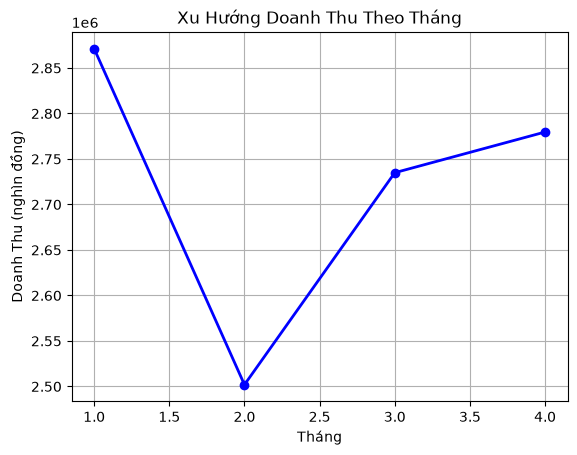

In [ ]:

trend_doanh_thu_thang = df_all.groupby(['Thang'])['DoanhThu'].sum().reset_index().sort_values('Thang')

# – Doanh thu theo tháng (Line chart).
plt.plot(trend_doanh_thu_thang['Thang'], trend_doanh_thu_thang['DoanhThu'], marker='o', color='blue', linewidth=2)
plt.title('Xu Hướng Doanh Thu Theo Tháng')
plt.xlabel('Tháng')
plt.ylabel('Doanh Thu (nghìn đồng)')
plt.grid(True)
plt.show()

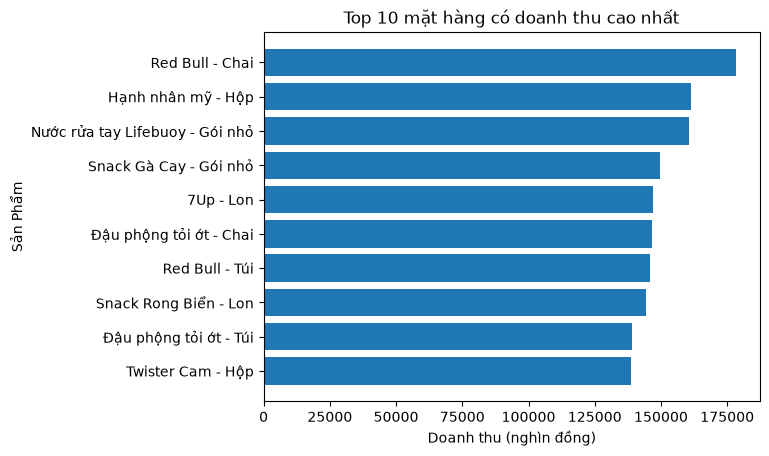

In [254]:
# – Top 10 mặt hàng có doanh thu cao nhất (Bar chart).
plt.barh(top_10_san_pham_doanh_thu_cao_nhat['TenHang'], top_10_san_pham_doanh_thu_cao_nhat['DoanhThu'])
plt.title('Top 10 mặt hàng có doanh thu cao nhất')
plt.xlabel('Doanh thu (nghìn đồng)')
plt.ylabel('Sản Phẩm')
plt.gca().invert_yaxis()
plt.show()

In [242]:
phan_tich_vi_tri

,ViTri,DoanhThuTB,SoLanGiaoDich
0,Khu công nghiệp,1096.341071,560
1,Khu dân cư,1069.520876,1461
2,Trung tâm thương mại,1086.911562,3053
3,Trường học,1088.024721,2953
4,Văn phòng,1104.882413,1973


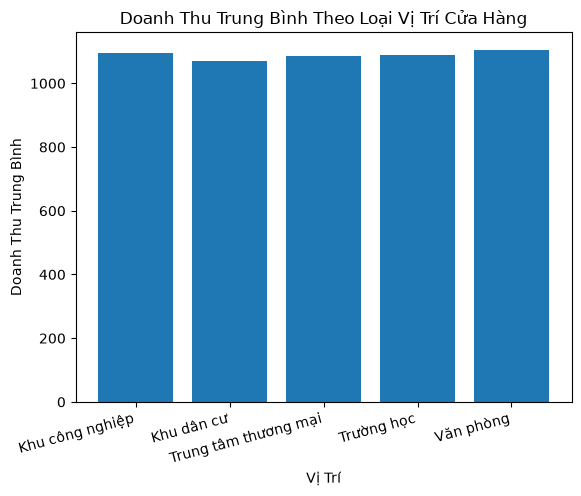

In [257]:
# So sánh doanh thu TB của các loại vị trí cửa hàng (Bar chart).
plt.bar(phan_tich_vi_tri['ViTri'], phan_tich_vi_tri['DoanhThuTB'])
plt.title('Doanh Thu Trung Bình Theo Loại Vị Trí Cửa Hàng')
plt.xlabel('Vị Trí')
plt.xticks(rotation=15, ha='right')
plt.ylabel('Doanh Thu Trung Bình')
plt.show()